# Identify Customer Segments

**Pipeline:**
> Youssef 
1. Data Exploration & Preprocessing
2. Feature Engineering & Encoding
3. Scaling
> Mohamed
4. PCA (Dimensionality Reduction)
5. K-Means Clustering
6. Market Profiling

---
## Step 0: Imports & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

%matplotlib inline
print('Libraries loaded.') 

Libraries loaded.


In [ ]:
# Load datasets
azdias = pd.read_csv(r"Udacity_AZDIAS_Subset.csv", sep=';')
customers = pd.read_csv(r"Udacity_CUSTOMERS_Subset.csv", sep=';')
feat_info = pd.read_csv('AZDIAS_Feature_Summary.csv', sep=';')

print('AZDIAS shape:   ', azdias.shape)
print('CUSTOMER shape: ', customers.shape)
print('feat_info shape:', feat_info.shape)

AZDIAS shape:    (891221, 85)
CUSTOMER shape:  (191652, 85)
feat_info shape: (85, 4)


---
## Step 1: Data Exploration

In [3]:
print(f'azdias head :')
print(azdias.head())

azdias head :
   AGER_TYP  ALTERSKATEGORIE_GROB  ANREDE_KZ  CJT_GESAMTTYP  \
0        -1                     2          1            2.0   
1        -1                     1          2            5.0   
2        -1                     3          2            3.0   
3         2                     4          2            2.0   
4        -1                     3          1            5.0   

   FINANZ_MINIMALIST  FINANZ_SPARER  FINANZ_VORSORGER  FINANZ_ANLEGER  \
0                  3              4                 3               5   
1                  1              5                 2               5   
2                  1              4                 1               2   
3                  4              2                 5               2   
4                  4              3                 4               1   

   FINANZ_UNAUFFAELLIGER  FINANZ_HAUSBAUER  ...  PLZ8_ANTG1  PLZ8_ANTG2  \
0                      5                 3  ...         NaN         NaN   
1                 

In [4]:
azdias.info()

<class 'pandas.DataFrame'>
RangeIndex: 891221 entries, 0 to 891220
Data columns (total 85 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   AGER_TYP               891221 non-null  int64  
 1   ALTERSKATEGORIE_GROB   891221 non-null  int64  
 2   ANREDE_KZ              891221 non-null  int64  
 3   CJT_GESAMTTYP          886367 non-null  float64
 4   FINANZ_MINIMALIST      891221 non-null  int64  
 5   FINANZ_SPARER          891221 non-null  int64  
 6   FINANZ_VORSORGER       891221 non-null  int64  
 7   FINANZ_ANLEGER         891221 non-null  int64  
 8   FINANZ_UNAUFFAELLIGER  891221 non-null  int64  
 9   FINANZ_HAUSBAUER       891221 non-null  int64  
 10  FINANZTYP              891221 non-null  int64  
 11  GEBURTSJAHR            891221 non-null  int64  
 12  GFK_URLAUBERTYP        886367 non-null  float64
 13  GREEN_AVANTGARDE       891221 non-null  int64  
 14  HEALTH_TYP             891221 non-null  int64  

In [5]:
print(f'feat info  head {feat_info.head()}')

feat info  head               attribute information_level         type missing_or_unknown
0              AGER_TYP            person  categorical             [-1,0]
1  ALTERSKATEGORIE_GROB            person      ordinal           [-1,0,9]
2             ANREDE_KZ            person  categorical             [-1,0]
3         CJT_GESAMTTYP            person  categorical                [0]
4     FINANZ_MINIMALIST            person      ordinal               [-1]


In [6]:
feat_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   attribute           85 non-null     str  
 1   information_level   85 non-null     str  
 2   type                85 non-null     str  
 3   missing_or_unknown  85 non-null     str  
dtypes: str(4)
memory usage: 2.8 KB


In [7]:
def build_unknown_map(feat_info):
    unknown_map = {}
    
    for _, row in feat_info.iterrows():
        attr = row['attribute']
        val = row['missing_or_unknown']
        
        if isinstance(val, str) and val != '[]':
            vals = val.strip('[]').split(',')
            cleaned = []
            
            for v in vals:
                v = v.strip().replace("'", "").replace('"', '')
                try:
                    v = int(v)
                except:
                    pass
                if v != '':
                    cleaned.append(v)
                    
            unknown_map[attr] = cleaned
    
    return unknown_map

UNKNOWN_MAP = build_unknown_map(feat_info)
print(f'Features with "unknown" values:\n{UNKNOWN_MAP}')

Features with "unknown" values:
{'AGER_TYP': [-1, 0], 'ALTERSKATEGORIE_GROB': [-1, 0, 9], 'ANREDE_KZ': [-1, 0], 'CJT_GESAMTTYP': [0], 'FINANZ_MINIMALIST': [-1], 'FINANZ_SPARER': [-1], 'FINANZ_VORSORGER': [-1], 'FINANZ_ANLEGER': [-1], 'FINANZ_UNAUFFAELLIGER': [-1], 'FINANZ_HAUSBAUER': [-1], 'FINANZTYP': [-1], 'GEBURTSJAHR': [0], 'HEALTH_TYP': [-1, 0], 'LP_LEBENSPHASE_FEIN': [0], 'LP_LEBENSPHASE_GROB': [0], 'LP_FAMILIE_FEIN': [0], 'LP_FAMILIE_GROB': [0], 'LP_STATUS_FEIN': [0], 'LP_STATUS_GROB': [0], 'NATIONALITAET_KZ': [-1, 0], 'PRAEGENDE_JUGENDJAHRE': [-1, 0], 'RETOURTYP_BK_S': [0], 'SEMIO_SOZ': [-1, 9], 'SEMIO_FAM': [-1, 9], 'SEMIO_REL': [-1, 9], 'SEMIO_MAT': [-1, 9], 'SEMIO_VERT': [-1, 9], 'SEMIO_LUST': [-1, 9], 'SEMIO_ERL': [-1, 9], 'SEMIO_KULT': [-1, 9], 'SEMIO_RAT': [-1, 9], 'SEMIO_KRIT': [-1, 9], 'SEMIO_DOM': [-1, 9], 'SEMIO_KAEM': [-1, 9], 'SEMIO_PFLICHT': [-1, 9], 'SEMIO_TRADV': [-1, 9], 'SHOPPER_TYP': [-1], 'SOHO_KZ': [-1], 'TITEL_KZ': [-1, 0], 'VERS_TYP': [-1], 'ZABEOTYP': [-1

In [8]:
def replace_unknowns(df, unknown_map):
    """Replace known unknown-encoding values with NaN, per column."""
    df = df.copy()
    for col, vals in unknown_map.items():
        if col in df.columns:
            df[col] = df[col].replace(vals, np.nan)
    return df

# Apply
azdias_recoded = replace_unknowns(azdias, UNKNOWN_MAP)
print('Unknown values replaced with NaN.')

Unknown values replaced with NaN.


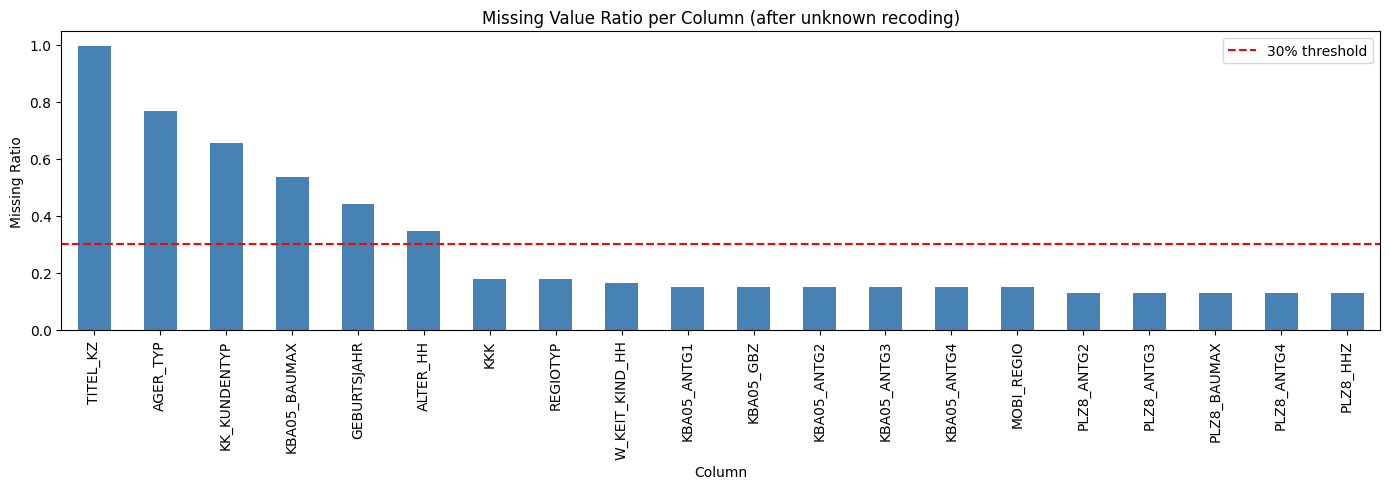


Columns with >30% missing:
TITEL_KZ        0.997576
AGER_TYP        0.769554
KK_KUNDENTYP    0.655967
KBA05_BAUMAX    0.534687
GEBURTSJAHR     0.440203
ALTER_HH        0.348137


In [9]:
# Missing ratio per column
missing_ratio = azdias_recoded.isnull().mean().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
missing_ratio.head(20).plot(kind='bar', color='steelblue')
plt.axhline(y=0.30, color='red', linestyle='--', label='30% threshold')
plt.title('Missing Value Ratio per Column (after unknown recoding)')
plt.ylabel('Missing Ratio')
plt.xlabel('Column')
plt.legend()
plt.tight_layout()
plt.show()

print('\nColumns with >30% missing:')
print(missing_ratio[missing_ratio > 0.30].to_string())

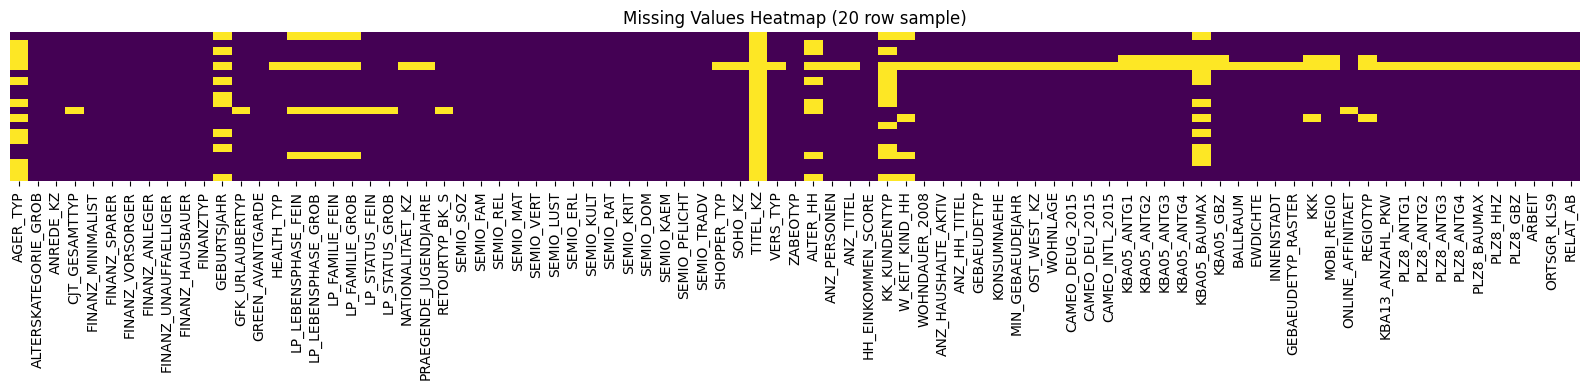

In [10]:
# Missing values heatmap on sample
sample = azdias_recoded.sample(20, random_state=42)
plt.figure(figsize=(16, 4))
sns.heatmap(sample.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap (20 row sample)')
plt.tight_layout()
plt.show()

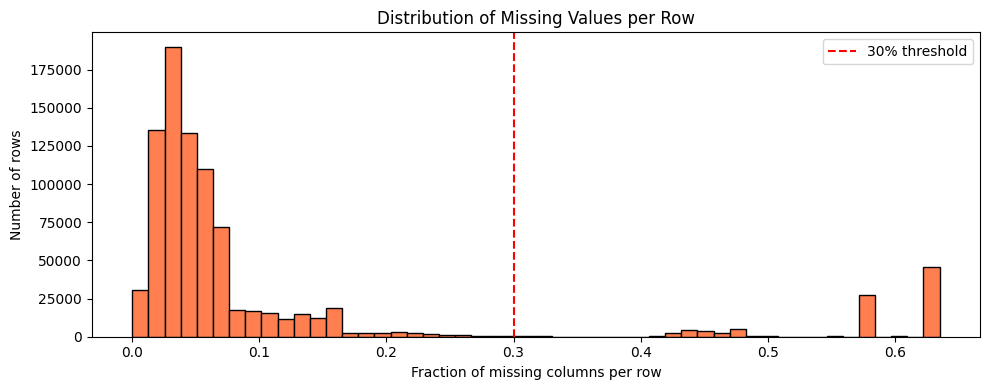

Rows with >30% missing: 93,837 (10.5%)


In [11]:
# Missing values per ROW distribution
row_missing = azdias_recoded.isnull().mean(axis=1)

plt.figure(figsize=(10, 4))
plt.hist(row_missing, bins=50, color='coral', edgecolor='black')
plt.axvline(x=0.30, color='red', linestyle='--', label='30% threshold')
plt.title('Distribution of Missing Values per Row')
plt.xlabel('Fraction of missing columns per row')
plt.ylabel('Number of rows')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Rows with >30% missing: {(row_missing > 0.30).sum():,} ({(row_missing > 0.30).mean():.1%})')

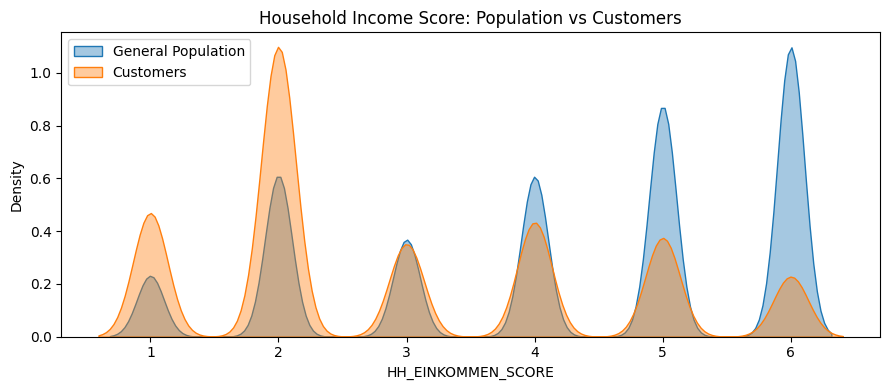

In [12]:
# Population vs Customers: Income comparison
customers_recoded = replace_unknowns(customers, UNKNOWN_MAP)

plt.figure(figsize=(9, 4))
sns.kdeplot(azdias_recoded['HH_EINKOMMEN_SCORE'].dropna(),    label='General Population', fill=True, alpha=0.4)
sns.kdeplot(customers_recoded['HH_EINKOMMEN_SCORE'].dropna(), label='Customers',           fill=True, alpha=0.4)
plt.title('Household Income Score: Population vs Customers')
plt.xlabel('HH_EINKOMMEN_SCORE')
plt.legend()
plt.tight_layout()
plt.show()

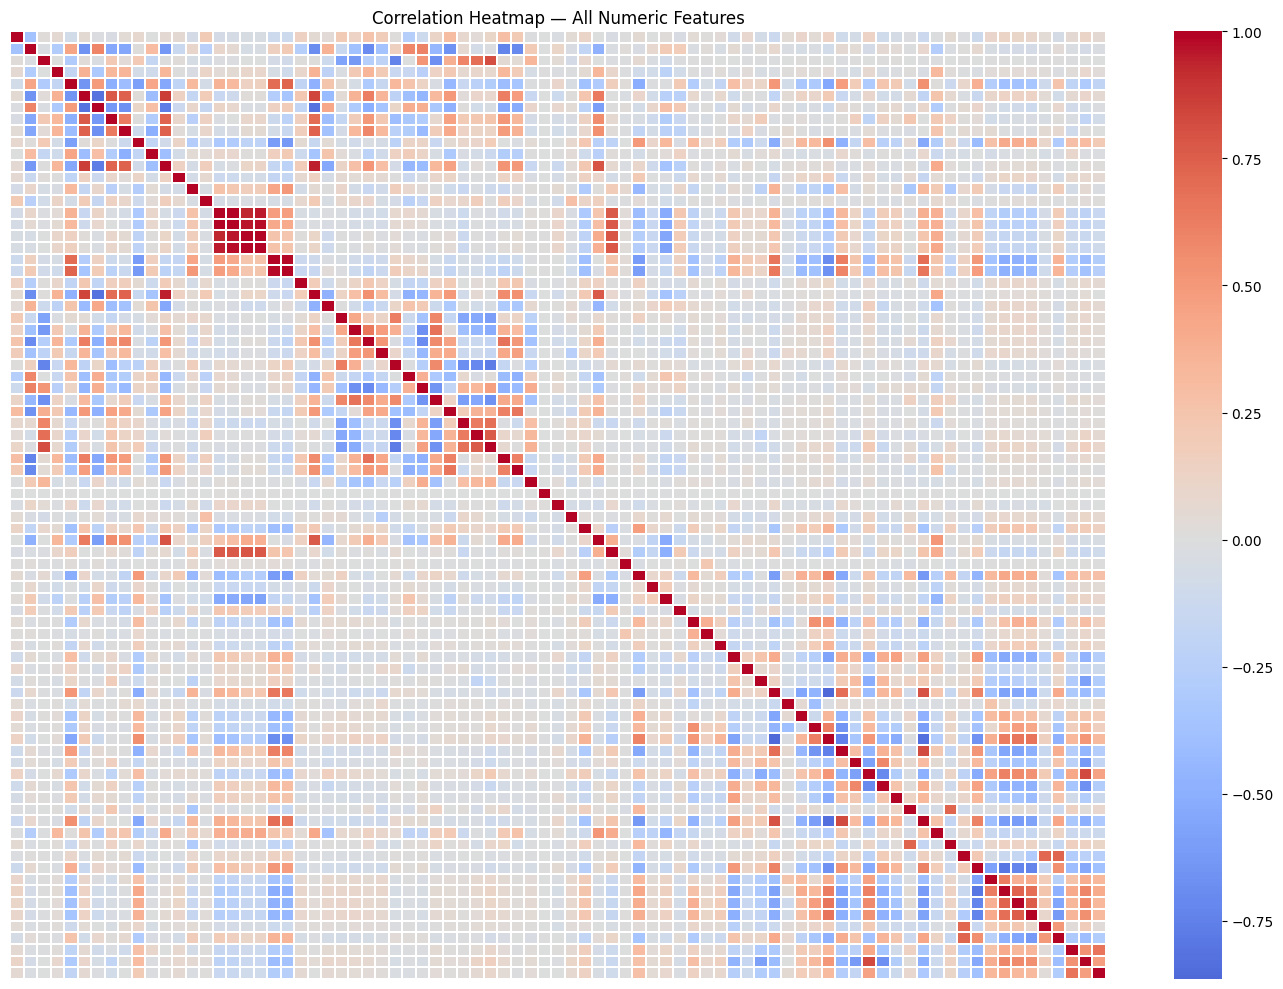

In [13]:
# Correlation heatmap
numeric_cols = azdias_recoded.select_dtypes(include=[np.number]).columns
corr = azdias_recoded[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3,
            xticklabels=False, yticklabels=False)
plt.title('Correlation Heatmap — All Numeric Features')
plt.tight_layout()
plt.show()

---
## Step 2: Preprocessing Pipeline

**Decisions made:**
- **Column threshold 30%:** Columns with >30% missing are dropped — too sparse to reliably impute.
- **Row threshold 30%:** Rows with >30% missing are dropped — these people lack enough demographic info to be useful.
- **PRAEGENDE_JUGENDJAHRE:** Split into `DECADE` (ordinal).
- **CAMEO_INTL_2015:** Split into `WEALTH` (1-5) and `LIFE_STAGE` (1-5).
- **Encoding:** Dummy variables via pd.get_dummies with drop_first=True.
- **Alignment:** Customers dataset is reindexed to perfectly match azdias.
- **Remaining NaN:** Filled with column median.

In [14]:
def engineer_features(df):
    """Feature engineering: split mixed-info columns."""
    df = df.copy()

    # PRAEGENDE_JUGENDJAHRE -> DECADE
    if 'PRAEGENDE_JUGENDJAHRE' in df.columns:
        df['DECADE'] = df['PRAEGENDE_JUGENDJAHRE']
        df = df.drop('PRAEGENDE_JUGENDJAHRE', axis=1)

    # CAMEO_INTL_2015 -> WEALTH + LIFE_STAGE
    if 'CAMEO_INTL_2015' in df.columns:
        df['CAMEO_INTL_2015'] = df['CAMEO_INTL_2015'].astype(str)
        df['WEALTH']     = pd.to_numeric(df['CAMEO_INTL_2015'].str[0], errors='coerce')
        df['LIFE_STAGE'] = pd.to_numeric(df['CAMEO_INTL_2015'].str[1], errors='coerce')
        df = df.drop('CAMEO_INTL_2015', axis=1)

    return df

In [15]:
attributes = feat_info[feat_info['type'] == 'categorical'].index
attributes

Index([0, 2, 3, 10, 12, 13, 17, 18, 19, 20, 21, 38, 39, 40, 41, 42, 47, 52, 55,
       57, 58],
      dtype='int64')

In [16]:
binary = []
multi_level = []

for attr in attributes:
    col_name = feat_info.loc[attr, 'attribute']
    if col_name in azdias.columns:
        if azdias[col_name].nunique(dropna=True) == 2:
            binary.append(col_name)
        else:
            multi_level.append(col_name)

print('Binary: {}'.format(binary))
print('Multi-level: {}'.format(multi_level))

Binary: ['ANREDE_KZ', 'GREEN_AVANTGARDE', 'SOHO_KZ', 'OST_WEST_KZ']
Multi-level: ['AGER_TYP', 'CJT_GESAMTTYP', 'FINANZTYP', 'GFK_URLAUBERTYP', 'LP_FAMILIE_FEIN', 'LP_FAMILIE_GROB', 'LP_STATUS_FEIN', 'LP_STATUS_GROB', 'NATIONALITAET_KZ', 'SHOPPER_TYP', 'TITEL_KZ', 'VERS_TYP', 'ZABEOTYP', 'KK_KUNDENTYP', 'GEBAEUDETYP', 'CAMEO_DEUG_2015', 'CAMEO_DEU_2015']


In [17]:
def encode_features(df):
    """Encode ordinal and nominal columns via dummies."""
    df = df.copy()
    df = pd.get_dummies(df, drop_first=True)
    return df

In [18]:
def full_pipeline(df, col_threshold=0.30, row_threshold=0.30):
    """Full preprocessing pipeline: recode -> drop -> engineer -> encode."""
    df = df.copy()

    # 1. Replace unknown encodings with NaN
    df = replace_unknowns(df, UNKNOWN_MAP)

    # 2. Drop high-missing columns
    col_missing = df.isnull().mean()
    cols_to_drop = col_missing[col_missing >= col_threshold].index.tolist()
    df = df.drop(columns=cols_to_drop)
    print(f'  Dropped {len(cols_to_drop)} columns with >= {col_threshold:.0%} missing')

    # 3. Drop high-missing rows
    row_missing = df.isnull().mean(axis=1)
    rows_before = len(df)
    df = df.loc[row_missing < row_threshold]
    print(f'  Dropped {rows_before - len(df):,} rows with >= {row_threshold:.0%} missing')

    # 4. Feature engineering
    df = engineer_features(df)

    # 5. Encode
    df = encode_features(df)

    return df

print('Pipeline functions defined.')

Pipeline functions defined.


In [19]:
print('Processing AZDIAS...')
azdias_clean = full_pipeline(azdias)

print('\nProcessing Customers...')
customers_clean = full_pipeline(customers)

# Align columns so Customers matches AZDIAS identically
customers_clean = customers_clean.reindex(
    columns=azdias_clean.columns,
    fill_value=0
)

# Final imputation with median
azdias_clean = azdias_clean.fillna(azdias_clean.median())
customers_clean = customers_clean.fillna(customers_clean.median())

print(f'\nFinal shape AZDIAS: {azdias_clean.shape}')
print(f'Final shape Customers: {customers_clean.shape}')

print(f'NaN in azdias_clean: {azdias_clean.isnull().sum().sum()}')
print(f'NaN in customers_clean: {customers_clean.isnull().sum().sum()}')

Processing AZDIAS...
  Dropped 6 columns with >= 30% missing
  Dropped 93,384 rows with >= 30% missing

Processing Customers...
  Dropped 8 columns with >= 30% missing
  Dropped 49,944 rows with >= 30% missing

Final shape AZDIAS: (797837, 129)
Final shape Customers: (141708, 129)
NaN in azdias_clean: 0
NaN in customers_clean: 0


---
## Step 3: Feature Scaling

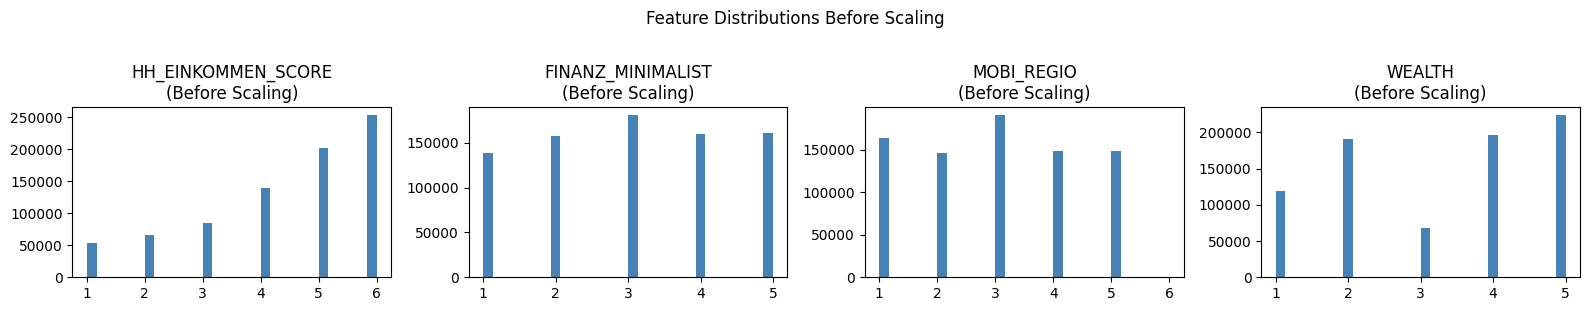

In [20]:
# Visualize a few features BEFORE scaling
viz_features = ['HH_EINKOMMEN_SCORE', 'FINANZ_MINIMALIST', 'MOBI_REGIO', 'WEALTH']
viz_features = [f for f in viz_features if f in azdias_clean.columns]

fig, axes = plt.subplots(1, len(viz_features), figsize=(16, 3))
for ax, col in zip(axes, viz_features):
    ax.hist(azdias_clean[col].dropna(), bins=30, color='steelblue', edgecolor='none')
    ax.set_title(f'{col}\n(Before Scaling)')
plt.suptitle('Feature Distributions Before Scaling', y=1.02)
plt.tight_layout()
plt.show()

In [21]:
# Fit scaler on AZDIAS only — transform customers with the same fitted scaler
scaler = StandardScaler()
azdias_scaled    = scaler.fit_transform(azdias_clean)
customers_scaled = scaler.transform(customers_clean)

# Verify no NaN
print(f'NaN in azdias_scaled:    {np.isnan(azdias_scaled).sum()}')
print(f'NaN in customers_scaled: {np.isnan(customers_scaled).sum()}')

NaN in azdias_scaled:    0
NaN in customers_scaled: 0


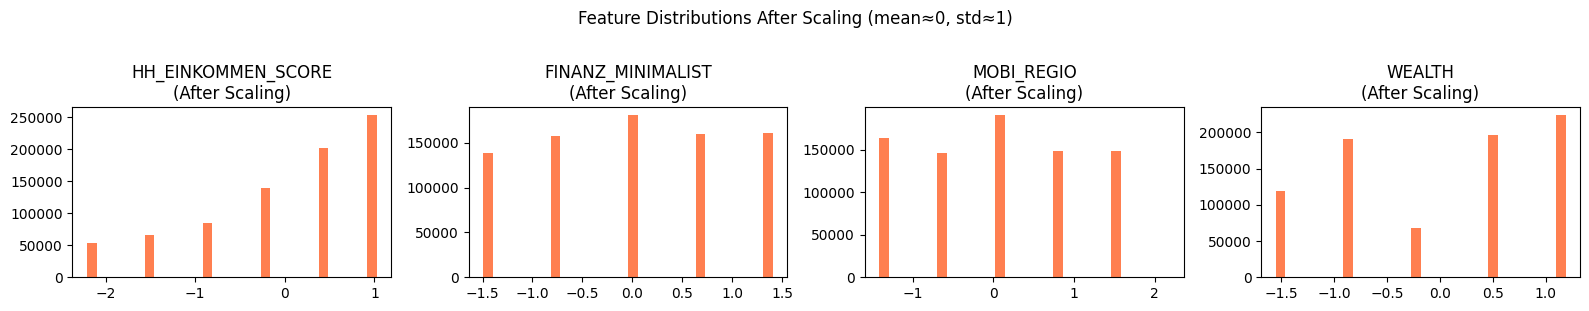

Mean of scaled features (should be ~0):
HH_EINKOMMEN_SCORE    0.0
FINANZ_MINIMALIST    -0.0
MOBI_REGIO            0.0
WEALTH               -0.0
dtype: float64


In [22]:
# Visualize the same features AFTER scaling
azdias_scaled_df = pd.DataFrame(azdias_scaled, columns=azdias_clean.columns)

fig, axes = plt.subplots(1, len(viz_features), figsize=(16, 3))
for ax, col in zip(axes, viz_features):
    if col in azdias_scaled_df.columns:
        ax.hist(azdias_scaled_df[col].dropna(), bins=30, color='coral', edgecolor='none')
        ax.set_title(f'{col}\n(After Scaling)')
plt.suptitle('Feature Distributions After Scaling (mean≈0, std≈1)', y=1.02)
plt.tight_layout()
plt.show()

print('Mean of scaled features (should be ~0):')
print(azdias_scaled_df[viz_features].mean().round(4))

> preprocessing Done -_-